In [1]:
import pandas as pd

df = pd.read_csv("netflix.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (1000, 7)


,title,rating,ratinglevel,ratingdescription,release_year,user_rating_score,user_rating_size
0,White Chicks,PG-13,"crude and sexual humor, language and some drug...",80,2004,82.0,80
1,Lucky Number Slevin,R,"strong violence, sexual content and adult lang...",100,2006,NaN,82
2,Grey's Anatomy,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2016,98.0,80
3,Prison Break,TV-14,Parents strongly cautioned. May be unsuitable ...,90,2008,98.0,80
4,How I Met Your Mother,TV-PG,Parental guidance suggested. May not be suitab...,70,2014,94.0,80


In [2]:
print("Dataset Information:\n")
df.info()

Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   title              1000 non-null   object 
 1   rating             1000 non-null   object 
 2   ratinglevel        941 non-null    object 
 3   ratingdescription  1000 non-null   int64  
 4   release_year       1000 non-null   int64  
 5   user_rating_score  605 non-null    float64
 6   user_rating_size   1000 non-null   int64  
dtypes: float64(1), int64(3), object(3)
memory usage: 54.8+ KB


In [3]:
print("Missing values:\n")
print(df.isnull().sum())

Missing values:

title                  0
rating                 0
ratinglevel           59
ratingdescription      0
release_year           0
user_rating_score    395
user_rating_size       0
dtype: int64


In [4]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 500


In [5]:
print("Rows before removing duplicates:", len(df))

df = df.drop_duplicates().reset_index(drop=True)

print("Rows after removing duplicates:", len(df))
print("Duplicates remaining:", df.duplicated().sum())

Rows before removing duplicates: 1000
Rows after removing duplicates: 500
Duplicates remaining: 0


In [6]:
df.describe()

,ratingdescription,release_year,user_rating_score,user_rating_size
count,500.000000,500.000000,256.000000,500.000000
mean,68.754000,2010.976000,81.398438,80.972000
std,31.505089,7.829305,12.730904,0.998604
min,10.000000,1940.000000,55.000000,80.000000
25%,41.000000,2009.000000,71.000000,80.000000
50%,70.000000,2014.000000,83.500000,80.000000
75%,90.000000,2016.000000,93.000000,82.000000
max,124.000000,2017.000000,99.000000,82.000000


In [7]:
print("Unique values in each column:\n")
print(df.nunique())

Unique values in each column:

title                496
rating                13
ratinglevel           99
ratingdescription     11
release_year          35
user_rating_score     42
user_rating_size       3
dtype: int64


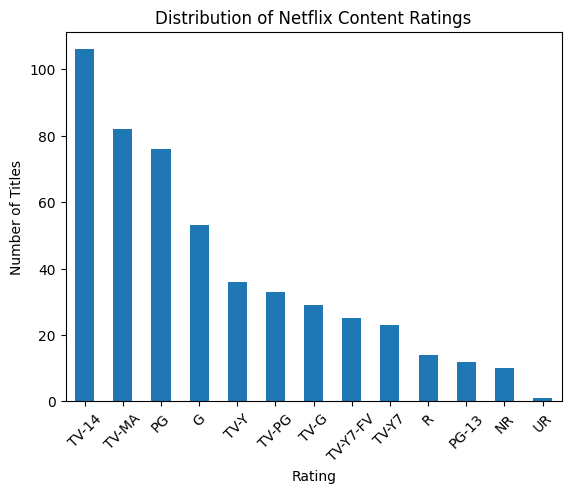

In [8]:
import matplotlib.pyplot as plt

df["rating"].value_counts().plot(kind="bar")

plt.title("Distribution of Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

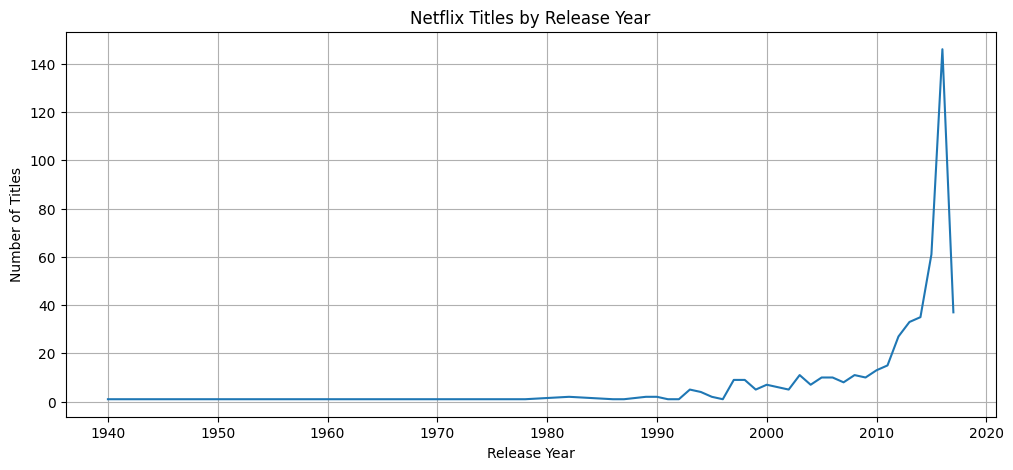

In [9]:
# Number of titles released each year
year_counts = df["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(year_counts.index, year_counts.values)

plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid()
plt.show()

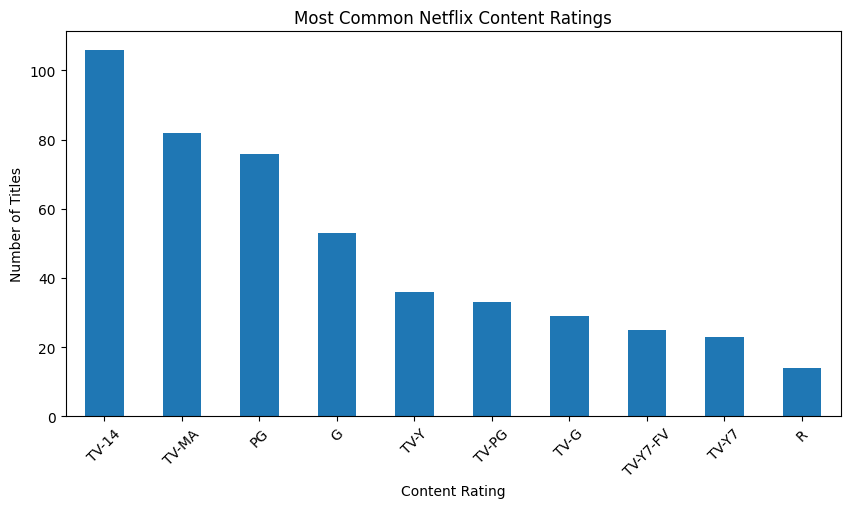

In [10]:
rating_counts = df["rating"].value_counts().head(10)

plt.figure(figsize=(10, 5))
rating_counts.plot(kind="bar")

plt.title("Most Common Netflix Content Ratings")
plt.xlabel("Content Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

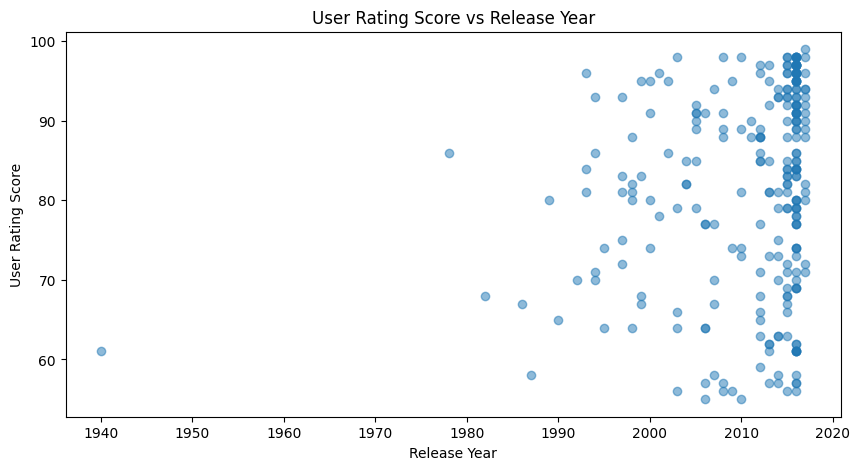

In [11]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df["release_year"],
    df["user_rating_score"],
    alpha=0.5
)

plt.title("User Rating Score vs Release Year")
plt.xlabel("Release Year")
plt.ylabel("User Rating Score")

plt.show()

In [12]:
average_rating = df["user_rating_score"].mean()

print("Average User Rating:", round(average_rating, 2))
print("Highest User Rating:", df["user_rating_score"].max())
print("Lowest User Rating:", df["user_rating_score"].min())

Average User Rating: 81.4
Highest User Rating: 99.0
Lowest User Rating: 55.0


In [13]:
top_10 = df[["title", "user_rating_score", "release_year"]].sort_values(
    by="user_rating_score",
    ascending=False
).head(10)

top_10

,title,user_rating_score,release_year
41,13 Reasons Why,99.0,2017
2,Grey's Anatomy,98.0,2016
8,The Walking Dead,98.0,2015
3,Prison Break,98.0,2008
27,The Flash,98.0,2016
25,Marvel's Iron Fist,98.0,2017
10,Once Upon a Time,98.0,2016
55,Family Guy,98.0,2015
63,Orange Is the New Black,98.0,2016
57,Friends,98.0,2003


In [14]:
print("Final Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Final Dataset Shape: (500, 7)
Missing Values: 277
Duplicate Rows: 0
